In [2]:
import pandas as pd
import numpy as np
import pickle

import mlflow

import matplotlib.pyplot as plt


RANDOM_STATE = 42
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000
EXPERIMENT_NAME = 'ilya_laptev'

In [3]:
items1 = pd.read_csv('data/item_properties_part1.csv')
items2 = pd.read_csv('data/item_properties_part2.csv')
events = pd.read_csv('data/events.csv')
category_tree = pd.read_csv('data/category_tree.csv')
items = pd.concat([items1, items2], ignore_index=True)

In [4]:
del items1
del items2

In [5]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 618.8+ MB


In [6]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [7]:
category_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


In [8]:
events['dt'] = pd.to_datetime(events['timestamp'], unit='ms')
items['dt'] = pd.to_datetime(items['timestamp'], unit='ms')
events.drop('timestamp', axis=1, inplace=True)
items.drop('timestamp', axis=1, inplace=True)

In [9]:
# Пропуски
print(f'items:\n{items.isna().sum()}\n\nevents:\n{events.isna().sum()}\n\ncategory tree:\n{category_tree.isna().sum()}')

items:
itemid      0
property    0
value       0
dt          0
dtype: int64

events:
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dt                     0
dtype: int64

category tree:
categoryid     0
parentid      25
dtype: int64


In [10]:
print(f'Количество пользователей: {events.visitorid.nunique()}')
print(f'Количество товаров: {items.itemid.nunique()}')

Количество пользователей: 1407580
Количество товаров: 417053


Количество событий по типам

In [11]:
events.event.value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [12]:
events['date'] = events['dt'].dt.date
events['hour'] = events['dt'].dt.hour
events['weekday'] = events['dt'].dt.weekday

In [13]:
# may_15 = events[
#     (events['dt'] >= '2015-05-01') &
#     (events['dt'] < '2015-06-01')
# ].copy()

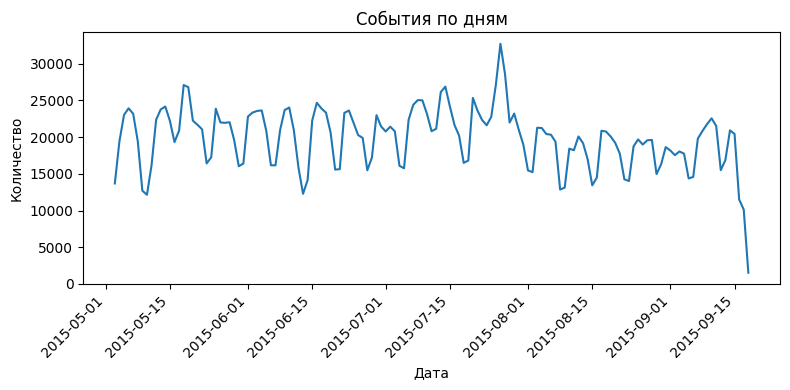

In [14]:
daily = events.groupby('date').size()
plt.figure(figsize=(8, 4))
daily.plot()
plt.title('События по дням')
plt.xlabel('Дата')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

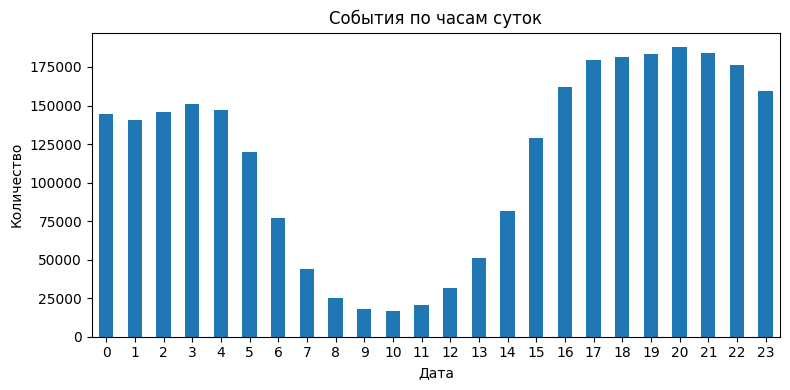

In [15]:
hourly = events.groupby('hour').size()
plt.figure(figsize=(8, 4))
hourly.plot(kind='bar')
plt.title('События по часам суток')
plt.xlabel('Дата')
plt.xticks(rotation=360)
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

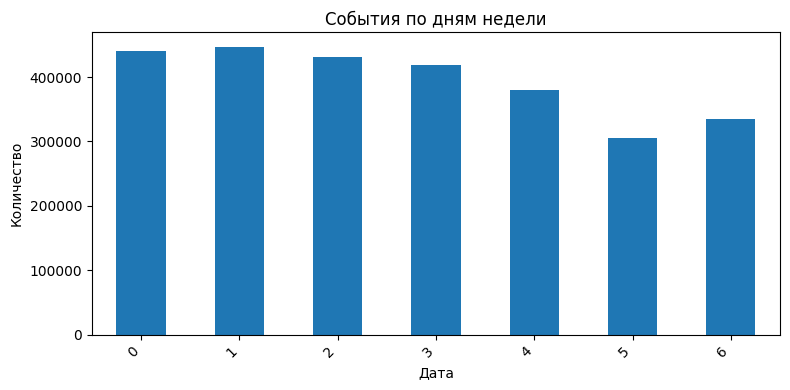

In [16]:
weekly = events.groupby('weekday').size()
plt.figure(figsize=(8, 4))
weekly.plot(kind='bar')
plt.title('События по дням недели')
plt.xlabel('Дата')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

In [17]:
evt_cnt = events['event'].value_counts()
evt_frac = events['event'].value_counts(normalize=True)
print(f'Абсолютно: {evt_cnt}')
print()
print(f'Доли: {evt_frac}')

Абсолютно: event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Доли: event
view           0.966696
addtocart      0.025156
transaction    0.008148
Name: proportion, dtype: float64


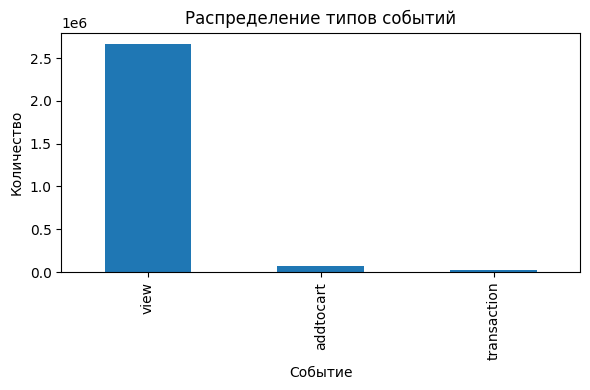

In [18]:
plt.figure(figsize=(6,4))
evt_cnt.plot(kind='bar')
plt.title('Распределение типов событий')
plt.xlabel('Событие')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

In [19]:
# events = events[events['event'].isin(['addtocart', 'transaction'])]

## Предобработка

Добавим столбец с весом каждого взаимодействия. Пусть будет так:

 - просмотр **1**
 - добавление в корзину **10** - это целевое действие, поэтому имеет наибольший вес
 - покупка **5**

In [20]:
event_weight = {
    'view': 1,
    'addtocart': 10,
    'transaction': 5
}

events['weights'] = events['event'].map(event_weight)
events = events.dropna(subset=['weights'])

In [21]:
events.drop(columns=['dt', 'hour', 'weekday'], inplace=True)

In [22]:
item_popularity = events.groupby('itemid')['weights'].agg('sum').reset_index().sort_values(by='weights', ascending=False)
item_popularity.head()

,itemid,weights
232496,461686,6264
94720,187946,3430
161235,320130,2908
157492,312728,2797
129504,257040,2556


In [22]:
item_popularity.to_parquet('data/item_popularity.parquet')

In [23]:
item_popularity.describe()

,itemid,weights
count,235061.000000,235061.000000
mean,233235.161707,14.761772
std,134799.765819,51.896696
min,3.000000,1.000000
25%,116287.000000,1.000000
50%,233448.000000,3.000000
75%,349821.000000,10.000000
max,466867.000000,6264.000000


Разделяю на обучающую и тестовую выборки

Оставляю в тренировочной выборке 80% событий

Закодируем пользователей и товары

In [23]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

events['user_idx'] = user_encoder.fit_transform(events['visitorid'])
events['item_idx'] = item_encoder.fit_transform(events['itemid'])

events = events.sort_values('date')
split_point = int(len(events) * 0.8)
cutoff_date = events.iloc[split_point]['date']
train_events = events[events['date'] <= cutoff_date].copy()
test_events = events[events['date'] > cutoff_date].copy()

print(f'Train до: {cutoff_date}, {len(train_events)} событий')
print(f'Test после: {cutoff_date}, {len(test_events)} событий')

Train до: 2015-08-18, 2220639 событий
Test после: 2015-08-18, 535462 событий


Сразу сохраняю энкодеры

In [25]:
with open('models/user_encoder.pkl', 'wb') as f:
    pickle.dump(user_encoder, f)
with open('models/item_encoder.pkl', 'wb') as f:
    pickle.dump(item_encoder, f)

Логирую энкодеры в mlflow

In [28]:
mlflow.set_tracking_uri(f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}')
mlflow.set_registry_uri(f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}')

In [29]:
RUN_NAME = 'log_encoders'
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id
    
with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    
    mlflow.log_artifact('models/user_encoder.pkl', artifact_path='encoders')
    mlflow.log_artifact('models/item_encoder.pkl', artifact_path='encoders')

Создаю разреженную матрицу для каждой выборки

In [31]:
user_item_train = csr_matrix(
    (train_events['weights'],
    (train_events['user_idx'], train_events['item_idx']))
)

user_item_test = csr_matrix(
    (test_events['weights'],
    (test_events['user_idx'], test_events['item_idx']))
)

Обучаю модель ALS для получения персональных рекомендаций

In [34]:
from implicit.als import AlternatingLeastSquares

params = {
    "factors": 64,
    "regularization": 0.05,
    "iterations": 50,
    "random_state": RANDOM_STATE
}

model = AlternatingLeastSquares(**params)
model.fit(user_item_train)

100%|██████████| 50/50 [02:23<00:00,  2.86s/it]


Сохранение модели

In [35]:
with open("models/als_model.pkl", "wb") as f:
    pickle.dump(model, f)

Логирую в mlflow

In [36]:
RUN_NAME = 'log_als_model'
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id
    
with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    
    mlflow.log_artifact('models/als_model.pkl', artifact_path='models')

In [37]:
# получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(len(user_encoder.classes_))

In [38]:
# получаем рекомендации для всех пользователей (для экономии времени по 5 штук)
als_recommendations = model.recommend(
    user_ids_encoded, 
    user_item_train[user_ids_encoded], 
    filter_already_liked_items=False, N=5)

In [39]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

als_recommendations = pd.DataFrame({
    "user_idx": user_ids_encoded,
    "item_idx": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})
als_recommendations = als_recommendations.explode(["item_idx", "score"], ignore_index=True)

# приводим типы данных
als_recommendations["item_idx"] = als_recommendations["item_idx"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")

# получаем изначальные идентификаторы
als_recommendations["user_id"] = user_encoder.inverse_transform(als_recommendations["user_idx"])
als_recommendations["item_id"] = item_encoder.inverse_transform(als_recommendations["item_idx"])
als_recommendations = als_recommendations.drop(columns=["user_idx", "item_idx"])

In [41]:
# Сохраним...
np.save('data/item_ids_enc.npy', item_ids_enc)
np.save('data/user_ids_encoded.npy', user_ids_encoded)

In [42]:
als_recommendations_1 = als_recommendations[["user_id", "item_id", "score"]]
als_recommendations_1.to_parquet("data/personal_als.parquet")

Рассчитаем похожие, они пригодятся для онлайн-рекоммендаций

In [43]:
train_items_idx_enc = train_events['item_idx'].unique()
max_similar_items = 5
similar_items = model.similar_items(train_items_idx_enc, N=max_similar_items)

similar_ii_idx_enc = similar_items[0]
similar_item_scores = similar_items[1]

In [44]:
# Сохраним похожие
np.savez("data/similar_items.npz", item_idx=similar_ii_idx_enc, scores=similar_item_scores)

In [45]:
# # Загрузка необходимых файлов для продолжения работы
# with np.load('data/similar_items.npz') as data:
#     similar_ii_idx_enc = data['item_idx']
#     similar_item_scores = data['scores']
    
# with open('models/item_encoder.pkl', 'rb') as f:
#     item_encoder = pickle.load(f)
# with open('models/user_encoder.pkl', 'rb') as f:
#     user_encoder = pickle.load(f)

In [46]:
train_item_idx_enc = train_events['item_idx'].unique()

similar_items = pd.DataFrame({
    'item_idx_enc': train_item_idx_enc,
    'similar_item_idx_enc': similar_ii_idx_enc.tolist(),
    'score': similar_item_scores.tolist()
})
similar_items = similar_items.explode(['similar_item_idx_enc', 'score'], ignore_index=True)

similar_items['similar_item_idx_enc'] = similar_items['similar_item_idx_enc'].astype('int')
similar_items['score'] = similar_items['score'].astype('float')

similar_items['item_idx_1'] = item_encoder.inverse_transform(similar_items['item_idx_enc'])
similar_items['item_idx_2'] = item_encoder.inverse_transform(similar_items['similar_item_idx_enc'])

similar_items = similar_items.drop(columns=['item_idx_enc', 'similar_item_idx_enc'])
similar_items = similar_items.query('item_idx_1 != item_idx_2')

In [47]:
similar_items.to_parquet("data/similar_items.parquet")

Сохраним итоговые данные для обучения модели ранжирования и финальных рекоммендаций

In [48]:
mlflow.set_tracking_uri(f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}')
mlflow.set_registry_uri(f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}')

In [49]:
RUN_NAME = 'predictions'
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id
    
with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    
    # Логирую данные для моделей
    mlflow.log_artifact('data/item_ids_enc.npy', artifact_path='mapping')
    mlflow.log_artifact('data/user_ids_encoded.npy', artifact_path='mapping')
    mlflow.log_artifact('data/similar_items.npz', artifact_path='mapping')
    
    # Логирую персональные рекомендации, похожие айтемы и топ популярных
    mlflow.log_artifact('data/personal_als.parquet', artifact_path='recs')
    mlflow.log_artifact('data/item_popularity.parquet', artifact_path='recs')
    mlflow.log_artifact('data/similar_items.parquet', artifact_path='recs')

### Все признаки готовы. Теперь построим модель ранжирования рекомендаций

Буду использовать библиотеку catboost

In [50]:
item_populatiry = pd.read_parquet('data/item_popularity.parquet')
personal_als = pd.read_parquet('data/personal_als.parquet')
similar_items = pd.read_parquet('data/similar_items.parquet')

In [51]:
# with open('models/item_encoder.pkl', 'rb') as f:
#     item_encoder = pickle.load(f)
# with open('models/user_encoder.pkl', 'rb') as f:
#     user_encoder = pickle.load(f)

In [62]:
train_events.event.value_counts()

event
view           2147199
addtocart        55405
transaction      18035
Name: count, dtype: int64

In [63]:
test_events.event.value_counts()

event
view           517113
addtocart       13927
transaction      4422
Name: count, dtype: int64

In [64]:
train_events['is_addtocart'] = (train_events['event'] == 'addtocart').astype(int)

# Добавляем популярность товаров
train_events = train_events.merge(
    item_popularity[['itemid', 'weights']].rename(columns={'weights': 'item_popularity'}),
    on='itemid',
    how='left'
)

In [65]:
train_events = train_events.merge(
    personal_als,
    left_on=['visitorid', 'itemid'],
    right_on=['user_id', 'item_id'],
    how='left'
)

In [66]:
# Предварительно переименуем столбцы для удобства
similar_items_renamed = similar_items.rename(columns={
    'item_idx_1': 'item_idx',
    'item_idx_2': 'similar_item_idx'
})

In [67]:
# Для каждого item_idx считаем средний score похожих товаров
similar_scores = similar_items_renamed.groupby('item_idx')['score'].mean().reset_index()
similar_scores.columns = ['item_idx', 'avg_similar_score']

In [68]:
# Добавляем в основной датасет
train_events = train_events.merge(similar_scores, on='item_idx', how='left')

In [69]:
train_events.fillna(0, inplace=True)

In [70]:
# Оставляем только нужные фичи для обучения ранжирующей модели
features_df = train_events[[
    'user_idx', 'itemid', 'item_idx',
    'item_popularity',  # из item_popularity
    'score',            # из personal_als
    'avg_similar_score',  # из similar_items
    'is_addtocart'       # целевая переменная
]]

In [71]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [73]:
features_df = features_df.rename(columns={'user_idx': 'group_id', 'is_addtocart': 'target'})

# Выбираем фичи и таргет
X = features_df.drop(columns=['target', 'group_id', 'itemid', 'item_idx'])
y = features_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [74]:
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

In [79]:
params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.1,
    "max_depth": -1,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "verbose": -1,
    "num_boost_round": 50
}

In [84]:
# Обучение модели
lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data]
)

In [85]:
# Предсказание релевантности
train_events["predicted_relevance"] = lgb_model.predict(X)
ranked_recommendations = train_events.sort_values(by=["visitorid", "predicted_relevance"], ascending=[True, False])

In [86]:
with open("models/lgb_model.pkl", "wb") as f:
    pickle.dump(lgb_model, f)

In [87]:
ranked_recommendations.to_parquet("data/recommendations.parquet")

Логирование модели и рекомендаций

In [88]:
RUN_NAME = 'final_recs'
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id
    
with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    
    mlflow.lightgbm.log_model(lgb_model, artifact_path='models')
    mlflow.log_params(params)
    mlflow.log_artifact('data/recommendations.parquet', artifact_path='final_recs')

# Оценка рекомендаций

In [24]:
ranked_recommendations = pd.read_parquet('data/recommendations.parquet')

In [25]:
ranked_recommendations = ranked_recommendations.drop(['user_id', 'item_id'], axis=1)

In [ ]:
def calculate_map_at_k(ranked_recommendations, test_events, k=10, sort_column='predicted_relevance'):
    # 1. Подготовка Ground Truth (только покупки)
    ground_truth = test_events[test_events['event'] == 'addtocart']
    user_to_true_items = ground_truth.groupby('visitorid')['itemid'].apply(set).to_dict()
    
    # 2. Подготовка рекомендаций (сортировка по заданному столбцу)
    user_to_recommendations = ranked_recommendations.groupby('visitorid').apply(
        lambda x: x.sort_values(sort_column, ascending=False)['itemid'].tolist()
    ).to_dict()
    
    average_precisions = []
    for user, true_items in user_to_true_items.items():
        if user not in user_to_recommendations:
            continue
        recommended_items = user_to_recommendations[user][:k]
        if not recommended_items:
            continue
            
        hits = 0
        sum_precision = 0.0
        for i, item in enumerate(recommended_items, 1):
            if item in true_items:
                hits += 1
                sum_precision += hits / i
        if hits > 0:
            avg_precision = sum_precision / min(len(true_items), k)
            average_precisions.append(avg_precision)
    return np.mean(average_precisions) if average_precisions else 0.0

In [30]:
k = 10
map_predicted = calculate_map_at_k(ranked_recommendations, test_events, k, 'predicted_relevance')
map_score = calculate_map_at_k(ranked_recommendations, test_events, k, 'score')
map_popularity = calculate_map_at_k(ranked_recommendations, test_events, k, 'item_popularity')

print(f"MAP@{k} (по predicted_relevance): {map_predicted:.4f}")
print(f"MAP@{k} (по score): {map_score:.4f}")
print(f"MAP@{k} (по популярности): {map_popularity:.4f}")

MAP@10 (по predicted_relevance): 1.4446
MAP@10 (по score): 1.5576
MAP@10 (по популярности): 1.5437


К сожалению я так и не смог понять, почему метрики приняли значения больше единицы, хотя не должны

In [31]:
mlflow.set_tracking_uri(f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}')
mlflow.set_registry_uri(f'http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}')

In [34]:
RUN_NAME = 'calculate_metrics'
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id
    
with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    
    k = 10
    mlflow.log_param("k", k)
    
    # Вычисляем MAP@K для разных способов ранжирования
    sort_columns = ['predicted_relevance', 'score', 'item_popularity']
    results = {}
    
    for column in sort_columns:
        map_k = calculate_map_at_k(ranked_recommendations, test_events, k, column)
        results[column] = map_k
        mlflow.log_metric(f"MAP_at_{k}_{column}", map_k)
    
    # Логируем результаты в виде таблицы (артефакт)
    results_df = pd.DataFrame.from_dict(results, orient='index', columns=['MAP@K'])
    results_df.to_parquet("data/mapk_results.parquet")
    mlflow.log_artifact("data/mapk_results.parquet", artifact_path='metrics')
    
    print(run_id)

6d2e2b3681ee42b6aa00c53ee8a0fe04


In [36]:
# 1. Создаём метку взаимодействия (если target > 0 — значит, было взаимодействие)
interacted_items = ranked_recommendations[ranked_recommendations["is_addtocart"] > 0][["visitorid", "itemid"]].copy()
interacted_items["interacted"] = True

In [37]:
# 2. Добавляем информацию о взаимодействиях в рекомендации
recommendations = ranked_recommendations.merge(interacted_items, on=["visitorid", "itemid"], how="left")
recommendations["interacted"] = recommendations["interacted"].fillna(False).astype(bool)

In [38]:
# 3. Проставляем ранги рекомендаций для каждого пользователя
recommendations = recommendations.sort_values(by=["visitorid", "predicted_relevance"], ascending=[True, False])
recommendations["rank"] = recommendations.groupby("visitorid").cumcount() + 1

In [39]:
# 4. Считаем novelty для топ-5 рекомендаций
novelty_5 = (1 - recommendations.query("rank <= 5").groupby("visitorid")["interacted"].mean())
mean_novelty_5 = novelty_5.mean()

In [40]:
# 5. Считаем coverage по логике из теории курса
recommended_items = recommendations.sort_values("predicted_relevance", ascending=False).head(100)["itemid"].nunique()
total_items = recommendations["itemid"].nunique()
coverage_score = recommended_items / total_items

In [41]:
# Вывод результатов
print(f"Coverage для топ-100: {coverage_score:}")
print(f"Novelty (по взаимодействиям): {mean_novelty_5:.2f}")

Coverage для топ-100: 4.681384940920922e-06
Novelty (по взаимодействиям): 0.98
